<a href="https://colab.research.google.com/github/Ashitharaj12/python_examples/blob/ashitha/FNN_ashitha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Import required libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt



In [5]:
# Load Dataset
data = pd.read_csv("climate_data.csv")  # Replace with actual dataset



In [7]:
X = data.drop(columns=["Energy Consumption"])  # Features (all columns except "Energy Consumption")
y = data["Energy Consumption"]  # Target variable (dependent variable)




Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3013751.7500 - mae: 1510.2574 - val_loss: 2726823.0000 - val_mae: 1436.1355
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2376801.5000 - mae: 1327.1757 - val_loss: 1087823.8750 - val_mae: 889.2408
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 707487.0625 - mae: 697.6841 - val_loss: 83359.8516 - val_mae: 256.4114
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54286.5781 - mae: 196.0589 - val_loss: 28147.6406 - val_mae: 128.8515
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28568.7109 - mae: 128.0834 - val_loss: 24001.1309 - val_mae: 120.6513
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23901.3613 - mae: 120.5043 - val_loss: 22582.3047 - val_mae: 118.5447
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 22021.9297 - mae: 116.8713 - val_loss: 21691.7344 - val_mae: 116.8571
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 21854.2148 - mae: 116.8416 - 

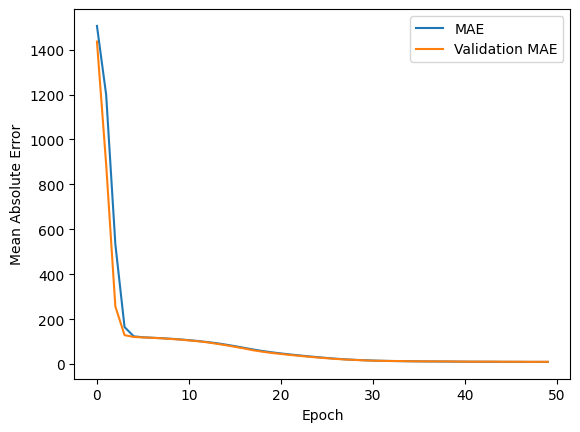

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the FNN Model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the Model
history = model.fit(X_train_scaled, y_train, epochs=50, validation_split=0.2, verbose=1)

# Evaluate the Model
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)
print(f"Test MAE: {test_mae}")

# Make Predictions
predictions = model.predict(X_test_scaled)

# Display the first few predictions
print(predictions[:5])

# Visualize Training History
plt.plot(history.history['mae'], label='MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()